![Ejercicio](https://i.gyazo.com/1e134f81dfa6f44e8002b808b36ae118.png "Ejercicio temperatura")

Solucion con Gauss Seidel
Radio espectral: 0.2
[42.37500006 14.12499999]
a0 =  42.375000057856
a1 =  14.124999988428801

Solucion con Jacobi
0.447213595499958
a0 =  [42.37499983 14.12499994]
a1 =  4.6284799282148015e-07


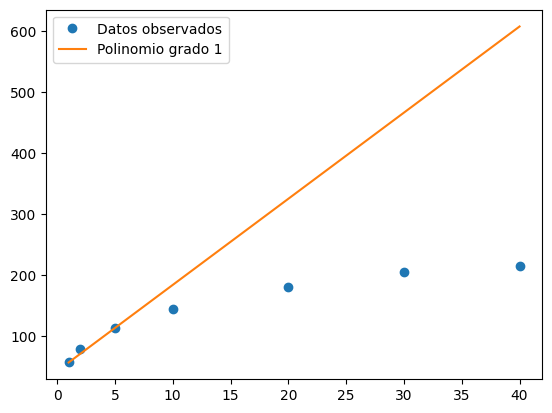

In [7]:
# Métodos de sistemas de ecuaciones lineales 

from metodo_gauss_seidel import gauss_seidel
from metodo_jacobi_con_matrices import jacobi_con_matrices
import numpy as np
import matplotlib.pyplot as plt

#solucion con gauss
Px = np.array([1,2,5,10,20,30,40])
Ty = np.array([56.5,78.6,113,144.5,181.0,205, 214.5])

A = np.array([[1, 1], [1, 5]], dtype=float)
b = np.array([56.5, 113], dtype=float)
x0 = np.zeros_like(b)

print("Solucion con Gauss Seidel")
coef = gauss_seidel(A, b, x0, 1e-6)
print(coef)
print("a0 = ", coef[0])
print("a1 = ", coef[1])

print("\nSolucion con Jacobi")
x_j = jacobi_con_matrices(A, b, x0, 1e-6)
print("a0 = ", x_j[0])
print("a1 = ", x_j[1])


#-----------------------------------

Pol = lambda x: coef[0] + coef[1]*x
u_x = np.linspace(min(Px), max(Px), 100)
plt.plot(Px, Ty, 'o', label="Datos observados")
plt.plot(u_x, Pol(u_x), label="Polinomio grado 1")
plt.legend()



![foto]( "Parte del ejercicio 2")

El grado del polinomio es la cantidad de datos - 1

Radio espectral: 0.4121729229296472


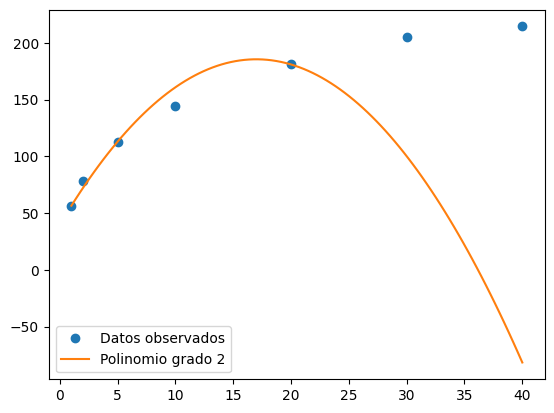

In [8]:
#Polinomio grado 2 MANUAL

Px = np.array([1,2,5,10,20,30,40])
Ty = np.array([56.5,78.6,113,144.5,181.0,205, 214.5])

A = np.array([[1, 1, 1], [1, 5, 5**2], [1, 20, 20**2]], dtype=float)
b = np.array([56.5, 113, 181], dtype=float)
x0 = np.zeros_like(b)
tol = 1e-6
coef = gauss_seidel(A, b, x0, tol)
Pol2 = lambda x: coef[0] + coef[1]*x + coef[2]*x**2
u_x = np.linspace(min(Px), max(Px), 100)
plt.plot(Px, Ty, 'o', label="Datos observados")
plt.plot(u_x, Pol2(u_x), label="Polinomio grado 2")
plt.legend()

![Polinomio con todos los datos](https://i.gyazo.com/3ef5dd4a35e79b0903b8bb75b2625036.jpg "Polinomio con todos los datos")

Radio espectral: 0.9810889703702437
La solución es: [ 2.46580134e+01  3.78906243e+01 -6.70414849e+00  6.90572258e-01
 -3.59349699e-02  8.82182388e-04 -8.09026454e-06]


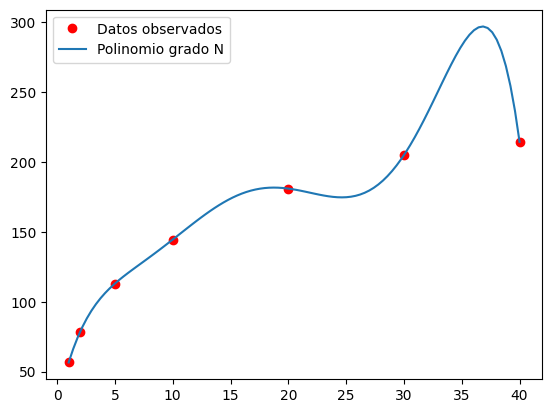

La aproximación para una presión de P=35atm es: 283.43725922084195


In [9]:
#POLINOMIO GRADO N AUTOMATICOo
import numpy as np

#Funciones para resolver el problema
def Matrix(Px):
    """
    Genera la matriz de coeficientes para dar solución.
    ----------
    Parametros:
    -----------
    Px : array
        Vector de puntos x
    Retorna:
    --------
    A : array
        Matriz de coeficientes
    ----------
    """
    n = len(Px)

    A = np.zeros([n, n])
    for i in range(n):
        A[i, 0] = 1
        for j in range(1, n):
            A[i, j] = A[i, j-1] * Px[i]
    return A

def polynom_generator(n):
    """
    Generador de polinomio de grado N.
    ----------
    Parametros:
    -----------
    n : int
        Grado del polinomio
    Retorna:
    --------
    pol_n : function
        Funcion que evalua el polinomio de grado N
    """
    pol_n = lambda x: sum([coef[i] * x**i for i in range(n)])
    return pol_n

#Datos del problema
Px = np.array([1,2,5,10,20,30,40])
Ty = np.array([56.5,78.6,113,144.5,181.0,205, 214.5])
A = Matrix(Px)
b = Ty
x0 = np.zeros_like(b)
tol = 1e-6

# Solución de gauss seidel
coef = gauss_seidel(A, b, x0, tol)
print(f"La solución es: {coef}")

# PolN = lambda x: coef[0][0] + coef[0][1]*x + coef[0][2]*x**2 + coef[0][3]*x**3 + coef[0][4]*x**4 + coef[0][5]*x**5 + coef[0][6]*x**6

# Generarador de polinomio de grado N
# pol_n = lambda x: sum([coef[0][i] * x**i for i in range(len(coef[0]))])

#Graficar el problema
pol_n = polynom_generator(len(coef))
u_x = np.linspace(min(Px), max(Px), 100)
plt.plot(Px, Ty, 'or', label="Datos observados")
plt.plot(u_x, pol_n(u_x), label="Polinomio grado N")
plt.legend()
plt.show()

print(f"La aproximación para una presión de P=35atm es: {pol_n(35)}")
